# CE 310 — Week 14 In-Class Exercise: Bootstrap Confidence Intervals

**CE 310 — Probability & Statistics for Civil & Architectural Engineering**
**University of Arizona**

---

Every interval you have built so far came out of a formula, and every formula
came with conditions attached — normal residuals, constant variance, a statistic
whose sampling distribution somebody has already worked out. The bootstrap drops
all of that. Resample the data you already have, recompute the statistic, and
read the interval off the spread of the results.

You will run it on the TxDOT bid tabulations from Weeks 11 and 12, where two of those
conditions visibly fail: awarded excavation prices are strongly right-skewed, and
the price model's residual spread shrinks as jobs get larger.

**Key concept:** the bootstrap resamples from the *data itself*, with
replacement, to estimate the sampling distribution of any statistic. Compare it
to Week 13's Monte Carlo, which sampled from distributions *you* specified. Monte
Carlo needs a model of the inputs; the bootstrap needs only the sample.


## Before You Begin

**File needed:** `CE310_BidItems_2024_2026.csv`
The same TxDOT bid tabulation you worked with in Weeks 11 and 12: 15,269 line-item
bids, of which 4,369 are for `EXCAV (ROADWAY)`.

**Upload options:**
1. **Colab Files panel (easiest):** Click the folder icon in the left sidebar → click the upload icon → select the CSV file from your computer.
2. **Google Drive mount:** Click the Drive mount button in the Files panel and navigate to the file.

> If you see `FileNotFoundError`, the CSV is not in Colab's working directory — go back and upload it first.


In [ ]:
# ── Identify your submission ─────────────────────────────────────────
# Fill both in before you run anything else. NETID is what matches your
# work to your student record — a blank NETID takes a 5-point deduction.
NAME  = ""   # e.g. "Jordan Reyes"
NETID = ""   # e.g. "jreyes"

print(f"NAME  = {NAME}")
print(f"NETID = {NETID}")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats

%matplotlib inline

In [ ]:
N_BOOT        = 1000
SEED          = 42
THRESHOLD_USD = 100.0            # a second-look price for roadway excavation
ITEM          = 'EXCAV (ROADWAY)'

df  = pd.read_csv('CE310_BidItems_2024_2026.csv')
exc = df[df['ItemDescription'] == ITEM].copy()
exc['LOW']  = (exc['LowBidder'] == 'Yes').astype(int)
exc['logq'] = np.log10(exc['Quantity'])
exc['logp'] = np.log10(exc['UnitPrice_USD'])

# Two different populations, and the week keeps them apart. Every bid on the
# item -- winners and losers -- is what the price model is fitted to. The
# awarded prices alone are what the agency actually paid.
won   = exc[exc['LOW'] == 1].reset_index(drop=True)
price = won['UnitPrice_USD'].values

N   = len(exc)
n   = len(won)
rng = np.random.default_rng(SEED)

print(f"Bids on {ITEM}: {N}   |   awarded: {n}")
print(f"Awarded price: mean ${price.mean():.2f}/CY, median ${np.median(price):.2f}/CY")


## Section A — Bootstrap Confidence Intervals: Fundamentals

Section A bootstraps three statistics: a mean, a percentile, and a regression
slope. The first and third have textbook formulas, so you can hold the resampled
interval up against the analytical one it would replace. The middle one has no
formula at all — and that is the case the bootstrap exists for.

> **How a bootstrap CI is built:**
> Draw *n* observations **with replacement** from your data, **N_BOOT** times.
> Each resample gives one estimate of your statistic.
> The 2.5th and 97.5th percentiles of those N_BOOT estimates are the **95% CI**.
>
> No assumption of normality, no known variance, and no need for anyone to have
> derived a standard error for your statistic. The sample supplies all three.

> ⚠️ **One `rng`, consumed in order.** Every cell below draws from the generator
> seeded once in the setup cell. Run the cells top to bottom, once each — re-running
> a cell advances the stream and changes every answer after it. If you lose track,
> use **Runtime → Restart and run all** rather than re-running cells by hand.


### A1–A4: Bootstrap CI for the Mean Awarded Price

`price` holds the unit price on each of the 555 awarded roadway-excavation
items — one row per job, losing bids filtered out. Bootstrap its mean, then set
the percentile interval beside the analytical *t*-interval for the same quantity.

Awarded prices are strongly right-skewed: the mean is $28.14/CY against a median
of $19.00/CY, and a handful of jobs clear $200/CY. A *t*-interval is symmetric
about the estimate by construction. Watch whether the bootstrap agrees that it
should be.


In [ ]:
# One bootstrap replicate: resample n awarded prices with replacement, take the mean.
boot_means_P = np.array([___ for _ in range(N_BOOT)])   # fill in: one replicate

ANSWER_A1 = round(___, 3)   # fill in: the mean of the bootstrap means
ANSWER_A2 = round(___, 5)   # fill in: their spread — the bootstrap SE
ANSWER_A3 = round(___, 3)   # fill in: the 2.5th percentile — lower CI end
ANSWER_A4 = round(___, 3)   # fill in: the 97.5th percentile — upper CI end

print(f"ANSWER_A1 = {ANSWER_A1}")
print(f"ANSWER_A2 = {ANSWER_A2}")
print(f"ANSWER_A3 = {ANSWER_A3}")
print(f"ANSWER_A4 = {ANSWER_A4}")

obs_mean = price.mean()
t_ci = stats.t.interval(0.95, df=n-1, loc=obs_mean, scale=stats.sem(price))
print(f"\nObserved mean awarded price : ${obs_mean:.3f}/CY")
print(f"Bootstrap 95% CI : [{ANSWER_A3}, {ANSWER_A4}]  width {ANSWER_A4 - ANSWER_A3:.3f}")
print(f"Analytical t-CI  : [{t_ci[0]:.3f}, {t_ci[1]:.3f}]  width {t_ci[1] - t_ci[0]:.3f}")
print(f"\nBootstrap reach below the mean: {obs_mean - ANSWER_A3:.3f}")
print(f"Bootstrap reach above the mean: {ANSWER_A4 - obs_mean:.3f}")


**Target shape:**

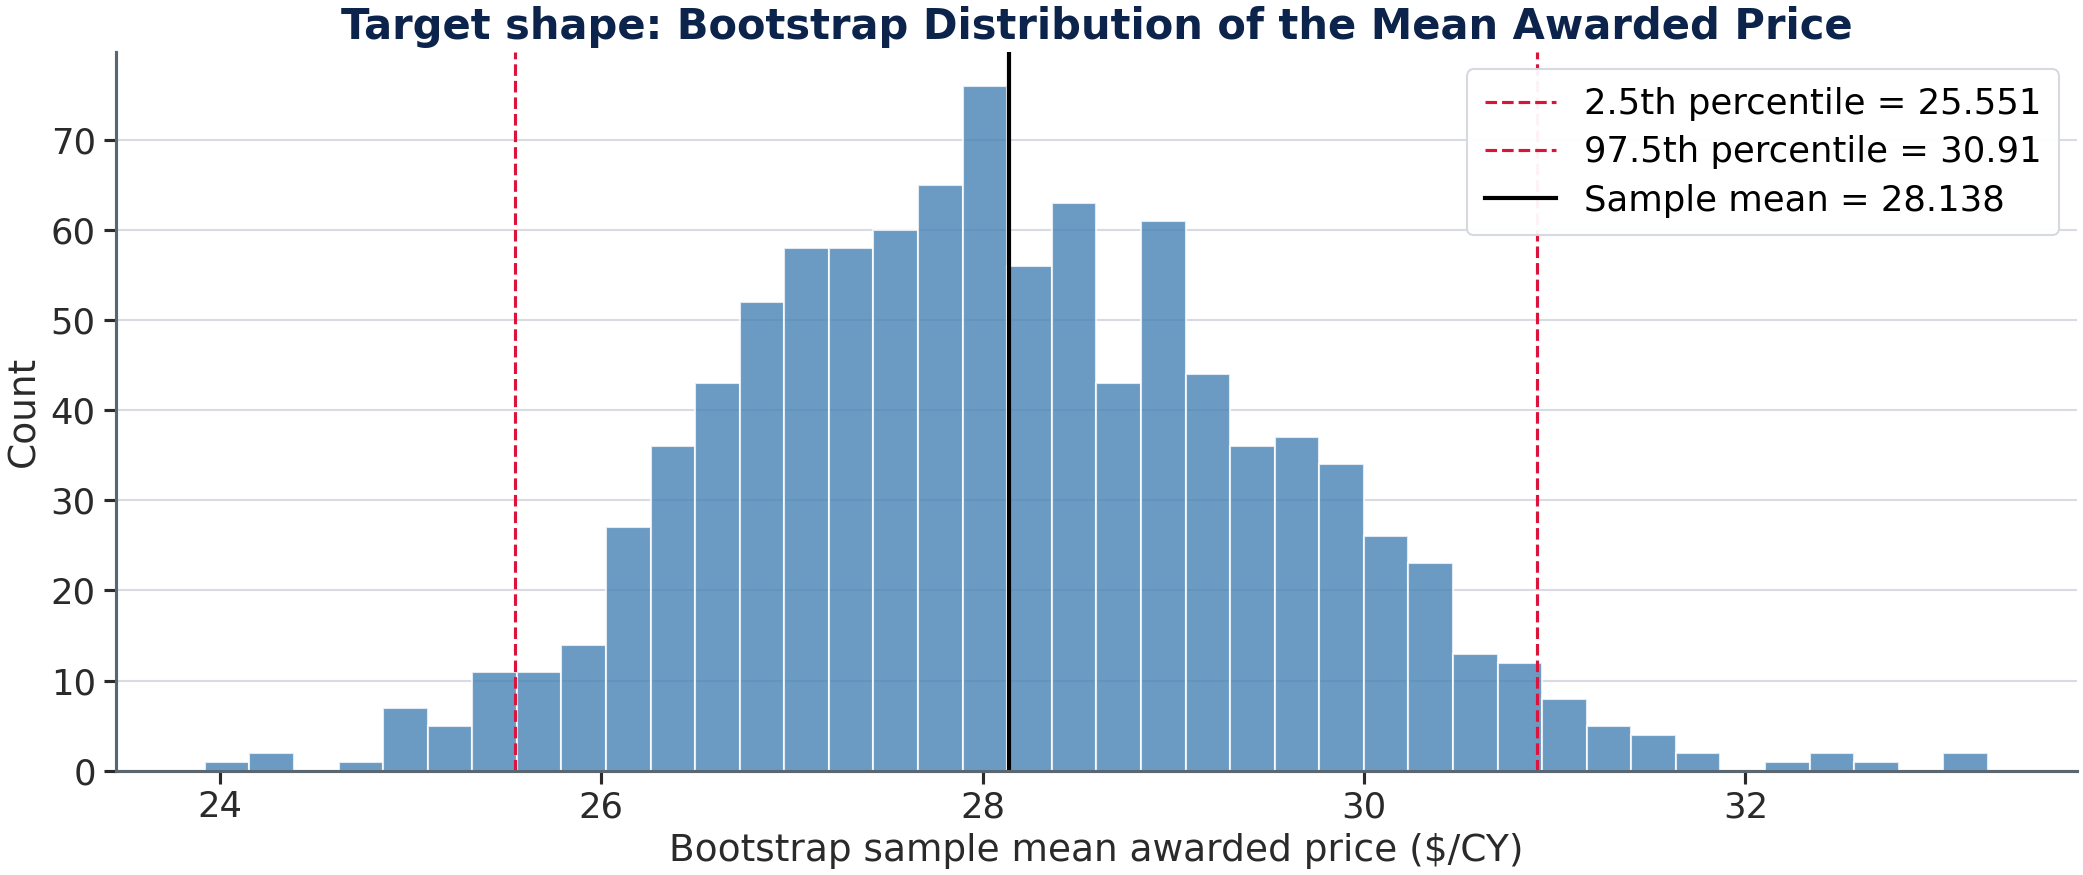


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boot_means_P, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(ANSWER_A3, color='crimson', linestyle='--', linewidth=1.5, label=f'2.5th percentile = {ANSWER_A3}')
ax.axvline(ANSWER_A4, color='crimson', linestyle='--', linewidth=1.5, label=f'97.5th percentile = {ANSWER_A4}')
ax.axvline(price.mean(), color='black', linestyle='-', linewidth=2, label=f'Sample mean = {price.mean():.3f}')
ax.set_xlabel('Bootstrap sample mean awarded price ($/CY)')
ax.set_ylabel('Count')
ax.set_title('Bootstrap Distribution of the Mean Awarded Price')
ax.legend()
plt.tight_layout()
plt.show()


### A5–A6: Bootstrap CI for the 95th Percentile of Awarded Price

An estimator setting a not-to-exceed line for roadway excavation cares about the
upper tail, not the average. The 95th percentile of awarded prices is that line:
5% of awarded jobs came in above it.

No textbook gives a standard error for a sample percentile. The bootstrap does
not need one — it treats a percentile exactly the way it treated the mean.


In [ ]:
# One bootstrap replicate: resample n awarded prices with replacement, take the 95th percentile.
boot_p95 = np.array([___ for _ in range(N_BOOT)])   # fill in: one replicate

ANSWER_A5 = round(___, 2)   # fill in: the 2.5th percentile — lower CI end
ANSWER_A6 = round(___, 2)   # fill in: the 97.5th percentile — upper CI end

print(f"ANSWER_A5 = {ANSWER_A5}")
print(f"ANSWER_A6 = {ANSWER_A6}")

obs_p95 = np.percentile(price, 95)
print(f"\nObserved P95 awarded price : ${obs_p95:.2f}/CY")
print(f"Bootstrap 95% CI for P95   : [{ANSWER_A5}, {ANSWER_A6}] $/CY")
print(f"Interval width             : ${ANSWER_A6 - ANSWER_A5:.2f}/CY "
      f"({100 * (ANSWER_A6 - ANSWER_A5) / obs_p95:.0f}% of the estimate)")


### A7–A8: Bootstrap CI for the Quantity Elasticity

Weeks 11 and 12 fitted `logp ~ logq` and read the slope as an elasticity: a job
ten times larger carries a unit price 10^slope times as high. Every cost forecast
in Week 12 rested on that number.

Use the **pairs bootstrap** — resample whole rows *(logq, logp)* together so the
predictor and the response stay attached, then refit. It assumes nothing about
the residuals, which matters here, because they are not well behaved.

> This cell refits the model 1,000 times on 4,369 rows. Expect a minute or so on
> Colab. A running cell is not a hung one.


In [ ]:
boot_slopes = []
for _ in range(N_BOOT):
    idx = ___                  # fill in: N row positions, drawn with replacement
    exc_b = exc.iloc[idx]
    m_b = smf.ols('logp ~ logq', data=exc_b).fit()
    boot_slopes.append(___)    # fill in: this refit's logq coefficient
boot_slopes = np.array(boot_slopes)

ANSWER_A7 = round(___, 4)   # fill in: the 2.5th percentile of the slopes
ANSWER_A8 = round(___, 4)   # fill in: the 97.5th percentile of the slopes

print(f"ANSWER_A7 = {ANSWER_A7}")
print(f"ANSWER_A8 = {ANSWER_A8}")

m1 = smf.ols('logp ~ logq', data=exc).fit()
ols_ci = m1.conf_int().loc['logq']
ols_ci_lower = ols_ci[0]
ols_ci_upper = ols_ci[1]
print(f"\nFitted elasticity          : {m1.params['logq']:.4f}")
print(f"Bootstrap 95% CI for slope : [{ANSWER_A7}, {ANSWER_A8}]")
print(f"Analytical OLS 95% CI      : [{ols_ci_lower:.4f}, {ols_ci_upper:.4f}]")


## Section B — Bootstrap for Model Diagnostics

Section A bootstrapped statistics that mostly had formulas, so you could check
the resampled interval against a known answer. Section B moves to quantities
where the formula is awkward, absent, or quietly wrong: a coefficient's interval
when the residuals misbehave, a p-value obtained by shuffling labels rather than
by assuming a distribution, an R² that OLS reports without any interval at all,
and a probability estimated from twenty events.

B8 closes the loop. It asks how far the resampled interval drifted from the
formula's — and the answer turns out to have a specific, checkable cause.


### B1–B4: Bootstrap CI for the Winner Discount and R²

Model 2 adds `LOW`, the indicator for the winning bid. Its coefficient is the
winner discount in log₁₀ dollars — the same effect Week 11 tested with a
two-sample *t*-test, now carrying an interval built without a distributional
assumption.

Bootstrap R² alongside it. OLS reports R² as a single number and never attaches
an interval to it; the bootstrap produces one at no extra cost.


In [ ]:
boot_LOW = []
boot_R2  = []
for _ in range(N_BOOT):
    idx = rng.integers(0, N, N)
    exc_b = exc.iloc[idx]
    m_b = smf.ols('logp ~ logq + LOW', data=exc_b).fit()
    boot_LOW.append(___)       # fill in: this refit's LOW coefficient
    boot_R2.append(___)        # fill in: this refit's R²
boot_LOW = np.array(boot_LOW)
boot_R2  = np.array(boot_R2)

ANSWER_B1 = round(___, 4)   # fill in: the 2.5th percentile of the LOW draws
ANSWER_B2 = round(___, 4)   # fill in: the 97.5th percentile of the LOW draws
ANSWER_B3 = round(___, 4)   # fill in: the mean of the bootstrap R² values
ANSWER_B4 = round(___, 4)   # fill in: the 2.5th percentile of those R² values

print(f"ANSWER_B1 = {ANSWER_B1}")
print(f"ANSWER_B2 = {ANSWER_B2}")
print(f"ANSWER_B3 = {ANSWER_B3}")
print(f"ANSWER_B4 = {ANSWER_B4}")

m2 = smf.ols('logp ~ logq + LOW', data=exc).fit()
ols_low_ci = m2.conf_int().loc['LOW']
print(f"\nBootstrap 95% CI for LOW coef : [{ANSWER_B1}, {ANSWER_B2}]  width {ANSWER_B2 - ANSWER_B1:.4f}")
print(f"Analytical OLS 95% CI for LOW : [{ols_low_ci[0]:.4f}, {ols_low_ci[1]:.4f}]  width {ols_low_ci[1] - ols_low_ci[0]:.4f}")
print(f"CI excludes zero? Bootstrap: {not (ANSWER_B1 <= 0 <= ANSWER_B2)} | OLS: {not (ols_low_ci[0] <= 0 <= ols_low_ci[1])}")
print(f"\nHolding job size fixed, that coefficient is a discount of "
      f"{100 * (1 - 10 ** m2.params['LOW']):.1f}% off what a losing bid quotes.")


# ── B4b/B4c: the other end of the interval, and the bootstrap SE ─────
# B4 records the 2.5th percentile of the bootstrap R² distribution. An
# interval needs both ends. And the standard deviation of the bootstrap
# coefficients is the bootstrap standard error — the quantity the whole
# resampling exercise exists to produce.

ANSWER_B4b_r2_ci_hi    = round(np.percentile(boot_R2, 97.5), 4)
ANSWER_B4c_boot_LOW_se = round(np.std(boot_LOW, ddof=1), 4)

print(f"ANSWER_B4b_r2_ci_hi = {ANSWER_B4b_r2_ci_hi}")
print(f"ANSWER_B4c_boot_LOW_se = {ANSWER_B4c_boot_LOW_se}")
print(f"\nOLS standard error on LOW : {m2.bse['LOW']:.4f}")


### Interpretation: What the Interval Settles, and What It Does Not *(4 pts — manually graded)*

**(written_B1)** The bootstrap 95% CI for the `LOW` coefficient is
[ANSWER_B1, ANSWER_B2], printed above alongside the OLS interval for the same
coefficient. Does the bootstrap interval exclude zero, and do the two methods
agree on its width? Then turn to R²: the bootstrap gives it an interval,
[ANSWER_B4, ANSWER_B4b_r2_ci_hi], where OLS reports a single number and no
interval at all. State what that interval tells a reviewer that the point
estimate on its own does not. (3–4 sentences)


YOUR INTERPRETATION HERE

### B5: Permutation Test — Is the Winner Discount Real?

Week 11 answered this with a two-sample *t*-test, which assumes a particular
sampling distribution for the difference in means. A permutation test assumes
nothing of the kind. Its logic is this: if the winning label carried no
information about price, then shuffling that label across the 4,369 bids should
produce gaps as large as the observed one reasonably often.

Shuffle the labels N_BOOT times, recompute the gap each time, and count how often
a shuffled gap matches or beats the real one. That count *is* the p-value.

> **Read the two discounts carefully — they are not the same number.** This test
> compares raw prices, with nothing held fixed. Model 2's `LOW` coefficient held
> job size fixed and came out smaller. Week 11 already found why: winners tend to
> bid the larger jobs (median 2,671 CY against 2,076 CY), and larger jobs carry
> lower unit prices, so part of the raw gap is which jobs winners bid on rather
> than how they price them. The cell prints both.


In [ ]:
low_yes  = exc.loc[exc['LOW'] == 1, 'logp'].values
low_no   = exc.loc[exc['LOW'] == 0, 'logp'].values
obs_diff = low_yes.mean() - low_no.mean()
combined = np.concatenate([low_yes, low_no])
n_yes    = len(low_yes)

perm_diffs = []
for _ in range(N_BOOT):
    shuffled = ___             # fill in: combined, reshuffled to break the label
    perm_diffs.append(___)     # fill in: the gap between the two halves
perm_diffs = np.array(perm_diffs)

ANSWER_B5 = round(___, 4)   # fill in: share of shuffles at least as extreme

print(f"ANSWER_B5 = {ANSWER_B5}")

t_stat, t_pval = stats.ttest_ind(low_yes, low_no)
print(f"\nObserved gap (winners minus losers): {obs_diff:.4f} log10 dollars")
print(f"  raw, nothing held fixed        : {100 * (1 - 10 ** obs_diff):.1f}% below losers")
print(f"  Model 2, holding job size fixed: {100 * (1 - 10 ** m2.params['LOW']):.1f}% below losers")
print(f"Largest gap in {N_BOOT} shuffles      : {np.abs(perm_diffs).max():.4f}")
print(f"Permutation test p-value           : {ANSWER_B5}")
print(f"Parametric t-test p-value          : {t_pval:.4e}")


# ── B5b: the difference the test is about ────────────────────────────
# B5 grades the p-value. Record the observed effect it refers to — a
# p-value is meaningless without the difference it is a statement about.

ANSWER_B5b_obs_diff = round(obs_diff, 4)

print(f"ANSWER_B5b_obs_diff = {ANSWER_B5b_obs_diff}")


### Comparison: Permutation Test vs. t-Test *(4 pts — manually graded)*

**(written_B2)** Both p-values are printed above. Do the two tests agree? A
permutation p-value of 0.0 does not mean the probability is zero — say what it
does mean when the test ran N_BOOT = 1000 shuffles, and what you would change to
report it more precisely. Then name one situation in which a permutation test and
a *t*-test would give meaningfully different answers on the same data.
(3–4 sentences)


YOUR COMPARISON HERE

### B6–B7: Bootstrap CI for an Exceedance Probability

A unit price far above the going rate is worth a second look: it can signal
unbalanced bidding, or a site condition the plans did not show. Take $100/CY on
roadway excavation as that line — roughly five times the typical awarded price.

The bootstrap will estimate the uncertainty in any statistic, and a probability
is a statistic like the rest. But note what it is working from: only 20 of the
555 awarded jobs cleared $100/CY. Estimating a probability from 20 events is a
different proposition from estimating a mean from 555, and the interval will
say so.


In [ ]:
boot_prob = np.array([(price[rng.integers(0, n, n)] > THRESHOLD_USD).mean() for _ in range(N_BOOT)])

ANSWER_B6 = round(___, 4)   # fill in: the 2.5th percentile of boot_prob
ANSWER_B7 = round(___, 4)   # fill in: the 97.5th percentile of boot_prob

print(f"ANSWER_B6 = {ANSWER_B6}")
print(f"ANSWER_B7 = {ANSWER_B7}")

obs_prob = (price > THRESHOLD_USD).mean()
print(f"\nJobs awarded above ${THRESHOLD_USD:.0f}/CY : {(price > THRESHOLD_USD).sum()} of {n}")
print(f"Observed P(price > ${THRESHOLD_USD:.0f}/CY)  : {obs_prob:.4f}")
print(f"Bootstrap 95% CI                : [{ANSWER_B6}, {ANSWER_B7}]")
print(f"The upper end is {ANSWER_B7 / ANSWER_B6:.1f}x the lower end.")


# ── B7b: the point estimate the interval brackets ────────────────────
# B6 and B7 are the two ends of a confidence interval for this
# probability. Record the observed value they are built around.

ANSWER_B7b_obs_prob = round((price > THRESHOLD_USD).mean(), 4)

print(f"ANSWER_B7b_obs_prob = {ANSWER_B7b_obs_prob}")


### B8: How Far the Resampled Interval Drifts From the Formula

Compare the width of your bootstrap CI for the Model 1 elasticity (A7–A8) to the
analytical OLS interval for the same slope. A ratio above 1 means OLS is quoting
more precision than the data actually supports.

If it does, that is a claim about this dataset and it ought to be checkable by
some route other than the bootstrap. The cell prints one.


In [ ]:
ols_ci_width  = ols_ci_upper - ols_ci_lower
boot_ci_width = ANSWER_A8 - ANSWER_A7

ANSWER_B8 = round(___, 3)   # fill in: the bootstrap width over the OLS width

print(f"ANSWER_B8 = {ANSWER_B8}")

print(f"\nBootstrap CI width : {boot_ci_width:.4f}")
print(f"OLS CI width       : {ols_ci_width:.4f}")
print(f"Ratio              : {ANSWER_B8}")
if ANSWER_B8 > 1:
    print("Ratio > 1 — the bootstrap interval is wider, so the OLS standard error")
    print("            understates how far this slope could sit from the truth.")
else:
    print("Ratio <= 1 — the bootstrap interval is no wider than the OLS one.")


# ── A second opinion, by a completely different route ────────────────
# An HC3 robust standard error corrects for non-constant residual
# variance using a formula, not resampling. If the bootstrap is picking
# up real structure rather than noise, the two corrections should land
# in the same place.

hc3 = m1.get_robustcov_results(cov_type='HC3')
print(f"\nOLS standard error on the slope : {m1.bse['logq']:.5f}")
print(f"HC3 robust standard error       : {hc3.bse[1]:.5f}"
      f"  ({hc3.bse[1] / m1.bse['logq']:.3f}x the OLS one)")

# And the reason both corrections fire: the residual spread is not constant.
spread = exc.assign(resid=m1.resid).groupby(
    pd.qcut(exc['logq'], 5, labels=['smallest', '2nd', '3rd', '4th', 'largest']),
    observed=True)['resid'].std()
print("\nResidual standard deviation, by job-size fifth:")
print(spread.round(4).to_string())


## Section C — When to Use the Bootstrap

The bootstrap earns its keep in two situations: when the parametric assumptions
are doubtful, and when the statistic you care about has no closed-form sampling
distribution at all. This in-class exercise has now shown you one of each.

It is not free, and it is not magic. It still assumes your sample is
representative of the population you want to describe — resampling 555 awarded
Texas jobs tells you about awarded Texas jobs and nothing else. What it removes
is the assumption about the *shape* of the sampling distribution, not the
assumption that your data are the right data.


### Reflection: When the Bootstrap Beats a Parametric CI *(4 pts — manually graded)*

**(written_reflection)** Name two situations in civil or architectural engineering
where a bootstrap interval would be more trustworthy than a parametric one — a
*t*-interval or an OLS standard error. For each, name the specific assumption the
parametric method makes and say why the data in that situation would violate it.
**At least one of your two examples must come from outside highway construction.**
(4–6 sentences)


YOUR REFLECTION HERE

---
### Technical Memo *(12 pts — manually graded)*

Write a **3-paragraph technical memo** addressed to your district's
cost-estimating lead, who is preparing next season's roadway-excavation budget.
Use the quantitative results from this in-class exercise. Target length: 150–250 words.

**Paragraph 1 — The Not-to-Exceed Line and Its Uncertainty:**
Report the bootstrap 95% CI for the P95 of awarded price (A5–A6) and the width of
that interval. Say what changes for an estimator who receives that line *with* an
interval instead of as a single number — and note that no formula would have
given them the interval at all.

**Paragraph 2 — Is the Winner Discount Real?**
Report the bootstrap CI for the `LOW` coefficient (B1–B2) and the permutation
result (B5). State whether the interval excludes zero, and say what the
permutation p-value adds that the interval alone does not.

**Paragraph 3 — Which Interval You Would Send Upstairs:**
Report your B8 ratio and say which method gives the wider interval for the
elasticity. Recommend which one you would put in front of the estimating lead,
and justify it using the residual-spread table and the HC3 standard error the
last cell printed — both of which point at the same assumption.

*Write your memo in the cell below.*


**MEMO**

**TO:** District Cost-Estimating Lead
**FROM:** [Your Name]
**DATE:** [Date]
**RE:** Bootstrap Uncertainty Estimates — Roadway Excavation Unit Prices

---

*Paragraph 1 — The Not-to-Exceed Line and Its Uncertainty:*
*(Replace this text.)*

*Paragraph 2 — Is the Winner Discount Real?*
*(Replace this text.)*

*Paragraph 3 — Which Interval You Would Send Upstairs:*
*(Replace this text.)*


## Before You Submit

- [ ] `NAME` and `NETID` filled in at the top and showing in the cell output — a blank `NETID` takes a 5-point deduction
- [ ] Every cell run in order, top to bottom (Runtime → Run all) — no errors, no cell left unrun
- [ ] Every `ANSWER_` line prints a value, and no `print(f"ANSWER_... = ...")` line edited or deleted
- [ ] Memo paragraphs are filled in (not placeholder text)
- [ ] Downloaded as `.ipynb` — not PDF, not `.py`
- [ ] Renamed `CE310_W14_<NetID>.ipynb` and uploaded to the Week 14 D2L dropbox